<a href="https://colab.research.google.com/github/Jason1xx/codefinity-introduction-to-python/blob/master/Assignment2_with_kaggle_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
df = pd.read_csv("AB_NYC_2019.csv")
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


This code reads the file " AB_NYC_2019.csv " and displays the first 5 rows of the dataset for a preview.

In [8]:
# This code displays the number of rows, columns, and cells in the dataset.
size = df.size
shape = df.shape

print(f"Size = {size}\nShape = {shape}")
print("Rows:", df.shape[0])
print("Cols:", df.shape[1])

Size = 782320
Shape = (48895, 16)
Rows: 48895
Cols: 16


This code displays and prints the total number of cells, rows and columns in the dataset.

In [9]:
# Basic statistics
print("\nBasic Statistics:")
display(df.describe(include="all"))


Basic Statistics:


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,48879,4.889500e+04,48874,48895,48895,48895.000000,48895.000000,48895,48895.000000,48895.000000,48895.000000,38843,38843.000000,48895.000000,48895.000000
unique,NaN,47905,NaN,11452,5,221,NaN,NaN,3,NaN,NaN,NaN,1764,NaN,NaN,NaN
top,NaN,Hillside Hotel,NaN,Michael,Manhattan,Williamsburg,NaN,NaN,Entire home/apt,NaN,NaN,NaN,2019-06-23,NaN,NaN,NaN
freq,NaN,18,NaN,417,21661,3920,NaN,NaN,25409,NaN,NaN,NaN,1413,NaN,NaN,NaN
mean,1.901714e+07,NaN,6.762001e+07,NaN,NaN,NaN,40.728949,-73.952170,NaN,152.720687,7.029962,23.274466,NaN,1.373221,7.143982,112.781327
std,1.098311e+07,NaN,7.861097e+07,NaN,NaN,NaN,0.054530,0.046157,NaN,240.154170,20.510550,44.550582,NaN,1.680442,32.952519,131.622289
min,2.539000e+03,NaN,2.438000e+03,NaN,NaN,NaN,40.499790,-74.244420,NaN,0.000000,1.000000,0.000000,NaN,0.010000,1.000000,0.000000
25%,9.471945e+06,NaN,7.822033e+06,NaN,NaN,NaN,40.690100,-73.983070,NaN,69.000000,1.000000,1.000000,NaN,0.190000,1.000000,0.000000
50%,1.967728e+07,NaN,3.079382e+07,NaN,NaN,NaN,40.723070,-73.955680,NaN,106.000000,3.000000,5.000000,NaN,0.720000,1.000000,45.000000
75%,2.915218e+07,NaN,1.074344e+08,NaN,NaN,NaN,40.763115,-73.936275,NaN,175.000000,5.000000,24.000000,NaN,2.020000,2.000000,227.000000


This code generates descriptive statistics for both numberic and categorical variables in the dataset. Showing the measures such as count, mean, standard deviation, minimum, maximum, and unique balues to help understand the distribution.

In [17]:
# Counts of missing values
print("\nMissing Values Count:")
display(df.isnull().sum().sort_values(ascending=False).to_frame("Missing Count"))


Missing Values Count:


,Missing Count
last_review,10052
reviews_per_month,10052
host_name,21
name,16
neighbourhood_group,0
neighbourhood,0
id,0
host_id,0
longitude,0
latitude,0


This code calculates and displays the number of missing values in each column of the dataset, sorting it from highest to lowest. This shows which values needs cleaning.

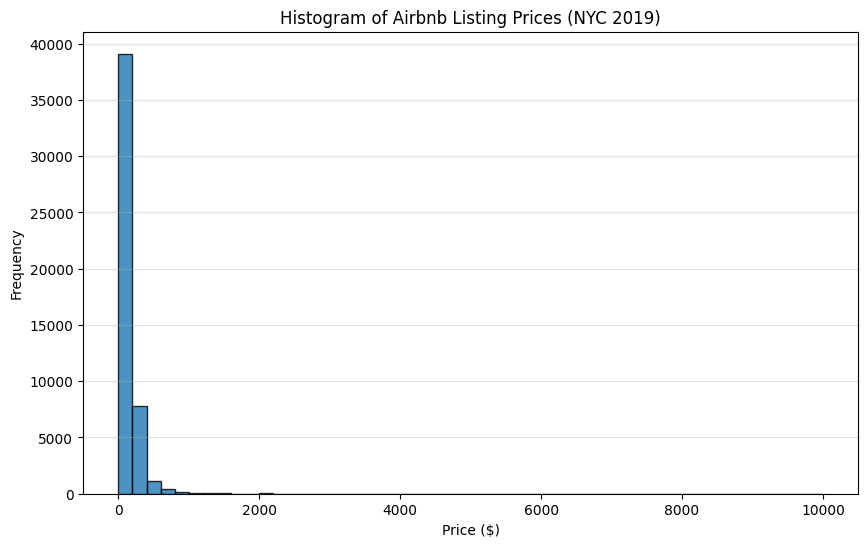

In [11]:
# Histogram of revenue data
plt.figure(figsize=(10, 6))
plt.hist(df["price"].dropna(), bins=50, edgecolor="black", alpha=0.8)
plt.title("Histogram of Airbnb Listing Prices (NYC 2019)")
plt.xlabel("Price ($)")
plt.ylabel("Frequency")
plt.grid(axis="y", alpha=0.4)
plt.show()

This code creates a histogram of Airbnb listing prices to show the distribution of prices helping us understand how most listings are priced and whether the data is skwed by extreme values.

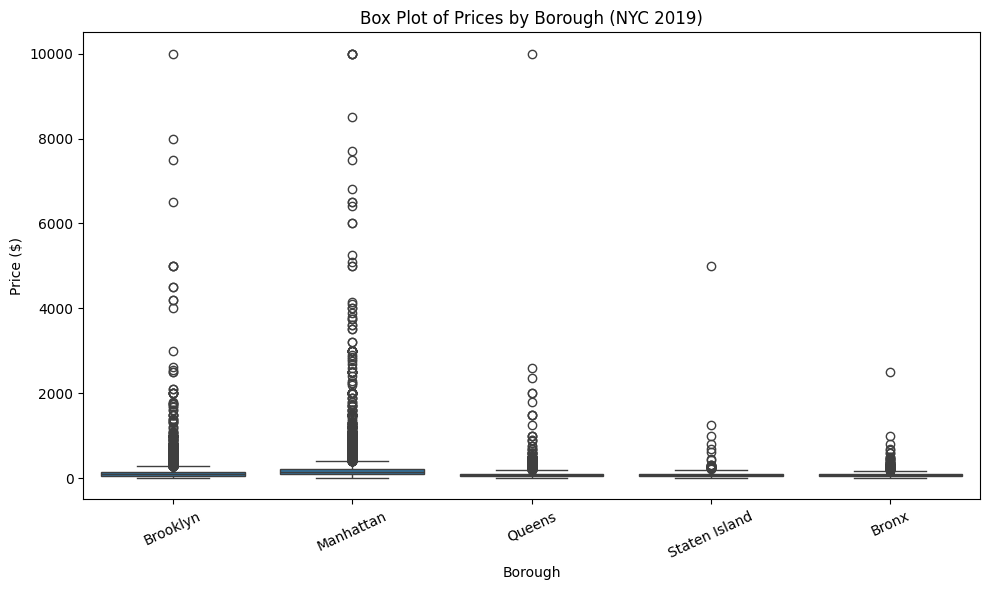

In [12]:
# Box plot by company and sector
plt.figure(figsize=(10, 6))
sns.boxplot(x="neighbourhood_group", y="price", data=df)
plt.title("Box Plot of Prices by Borough (NYC 2019)")
plt.xlabel("Borough")
plt.ylabel("Price ($)")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

This code creates a box plot showing the distribution of AirBnb Listings prices across different NYC Boroughs, this allows us to compare median prices, price spread, and identify outliers.

In [13]:
# Identifying outliers in P/E ratio using Z-score
price = df["price"].dropna()
z_scores = (price - price.mean()) / price.std()

outlier_prices = price[abs(z_scores) > 3]
outliers_df = df.loc[outlier_prices.index, ["name", "neighbourhood_group", "neighbourhood", "room_type", "price"]]

print("Outliers in Price (|Z-score| > 3):", outliers_df.shape[0])
display(outliers_df.sort_values("price", ascending=False).head(20))

Outliers in Price (|Z-score| > 3): 388


,name,neighbourhood_group,neighbourhood,room_type,price
17692,Luxury 1 bedroom apt. -stunning Manhattan views,Brooklyn,Greenpoint,Entire home/apt,10000
29238,1-BR Lincoln Center,Manhattan,Upper West Side,Entire home/apt,10000
9151,Furnished room in Astoria apartment,Queens,Astoria,Private room,10000
40433,2br - The Heart of NYC: Manhattans Lower East ...,Manhattan,Lower East Side,Entire home/apt,9999
6530,Spanish Harlem Apt,Manhattan,East Harlem,Entire home/apt,9999
12342,"Quiet, Clean, Lit @ LES & Chinatown",Manhattan,Lower East Side,Private room,9999
30268,Beautiful/Spacious 1 bed luxury flat-TriBeCa/Soho,Manhattan,Tribeca,Entire home/apt,8500
4377,Film Location,Brooklyn,Clinton Hill,Entire home/apt,8000
29662,East 72nd Townhouse by (Hidden by Airbnb),Manhattan,Upper East Side,Entire home/apt,7703
45666,Gem of east Flatbush,Brooklyn,East Flatbush,Private room,7500


This code shows the Airbnb listings with high or low prices by calculating the Z-score for the price and filitering listings with prices more than 3 standard deviations away from the mean, then displaying the most extreme lsitings.

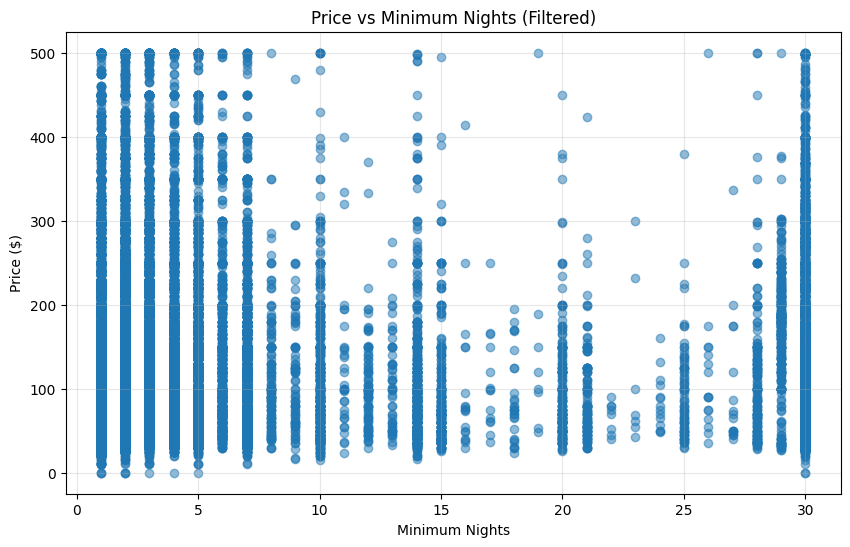

In [16]:
# Scatter plot of profit vs. revenue
filtered_df = df[(df["price"] <= 500) & (df["minimum_nights"] <= 30)]

plt.figure(figsize=(10, 6))
plt.scatter(filtered_df["minimum_nights"], filtered_df["price"], alpha=0.5)

plt.title("Price vs Minimum Nights (Filtered)")
plt.xlabel("Minimum Nights")
plt.ylabel("Price ($)")
plt.grid(True, alpha=0.3)

plt.show()

This code creates a scatter plot showeing the distinction between minimum nights required and listing price.

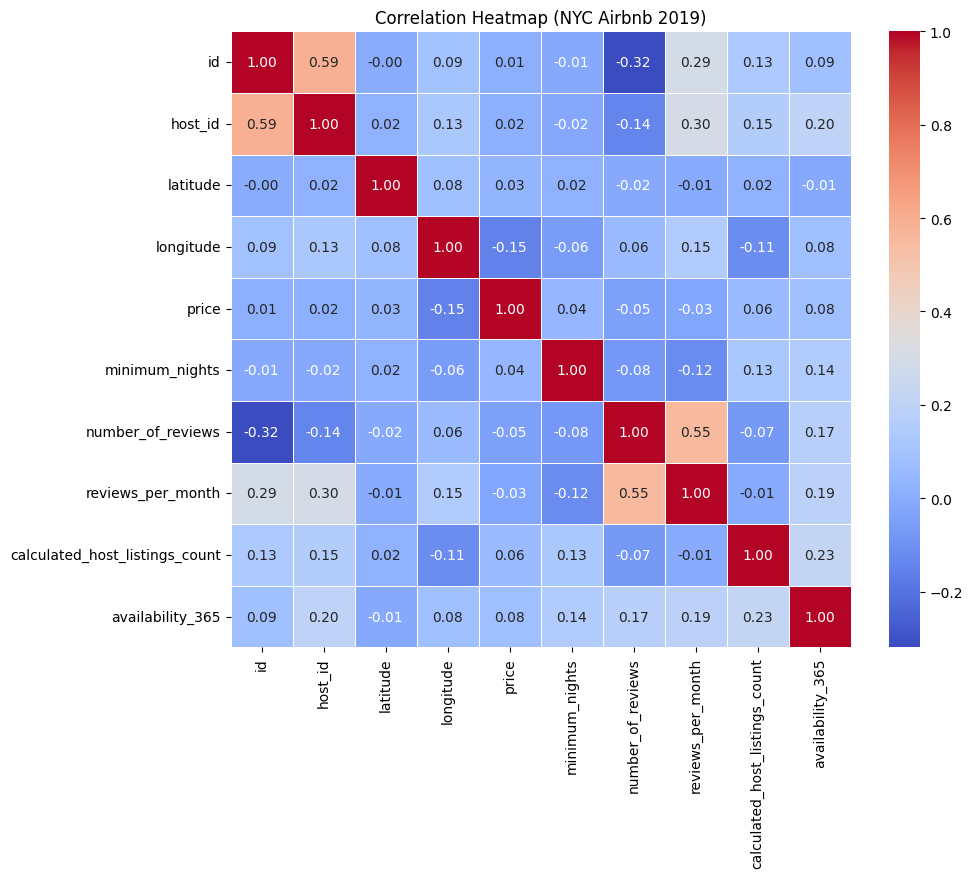

In [15]:
# Correlation heatmap
plt.figure(figsize=(10, 8))

correlation = df.select_dtypes(include=['number']).corr()

sns.heatmap(correlation, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)

plt.title("Correlation Heatmap (NYC Airbnb 2019)")
plt.show()


This code shows the correlations between all of the numeric variables in the dataset and displays them in a heatmap to show the strength and direction between features like price, avaiability, and number of reviews.